# LunarLander-v3 RL Final Project
## Training and Evaluation Notebook

This notebook presents the learning curves and evaluation results for both the Primary (DQN) and Bonus (PPO) tracks.
The full training loops and network architectures are implemented in `train_dqn.py`, `dqn_agent.py`, `train_ppo.py`, and `ppo_agent.py`.

Both agents were evaluated strictly under the 150,000 steps per seed budget constraint. The training artifacts (JSON metrics and PNG plots) saved by the training scripts are loaded and visualized below.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

## 1. Deep Q-Network (DQN) Results (Primary Track)
The DQN agent was trained on 3 different seeds (42, 123, 456). A 3-layer MLP architecture (8->128->128->4) was used with experience replay and a target network.

=== DQN Evaluation Results ===
Mean return across seeds: 201.6
Standard deviation: 40.4
Best seed: 42 with return: 231.2

Loading Learning Curves Plot...


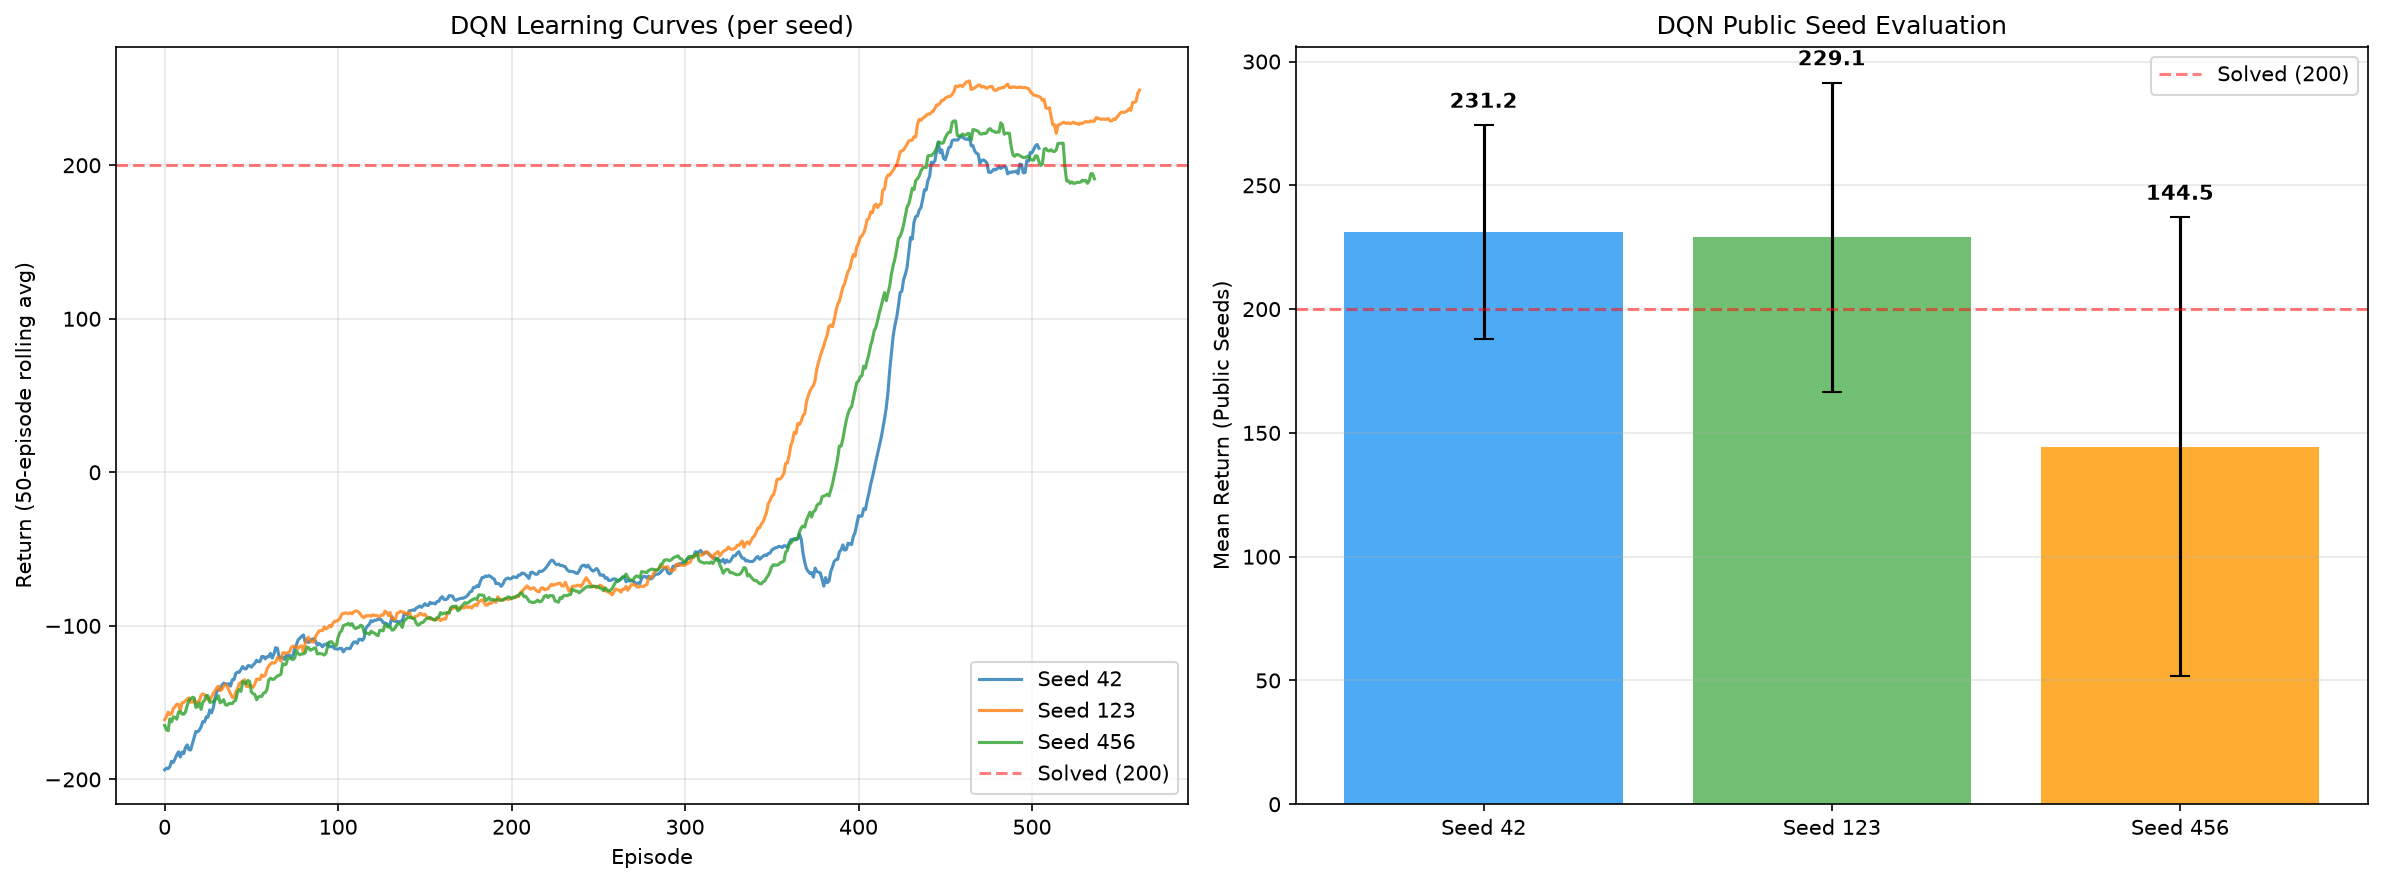

In [2]:
with open('checkpoints/dqn_results.json', 'r') as f:
    dqn_results = json.load(f)

means = [r['public_eval_mean'] for r in dqn_results]
best_idx = np.argmax(means)
best_seed = dqn_results[best_idx]['seed']

print("=== DQN Evaluation Results ===")
print(f"Mean return across seeds: {np.mean(means):.1f}")
print(f"Standard deviation: {np.std(means):.1f}")
print(f"Best seed: {best_seed} with return: {means[best_idx]:.1f}")
print("\nLoading Learning Curves Plot...")
display(Image(filename='plots/dqn_learning_curves.png'))

## 2. Proximal Policy Optimization (PPO) Results (Bonus Track)
The PPO agent uses separate actor and critic networks (64 hidden units), orthogonal initialization, and GAE. It was also trained for exactly 150,000 steps per seed. As PPO is an on-policy method, 150K steps is extremely challenging and generally insufficient to solve the environment, which is reflected in the scores.

=== PPO Evaluation Results ===
Mean return across seeds: -510.7
Standard deviation: 116.6
Best seed: 123 with return: -352.0

Loading Learning Curves Plot...


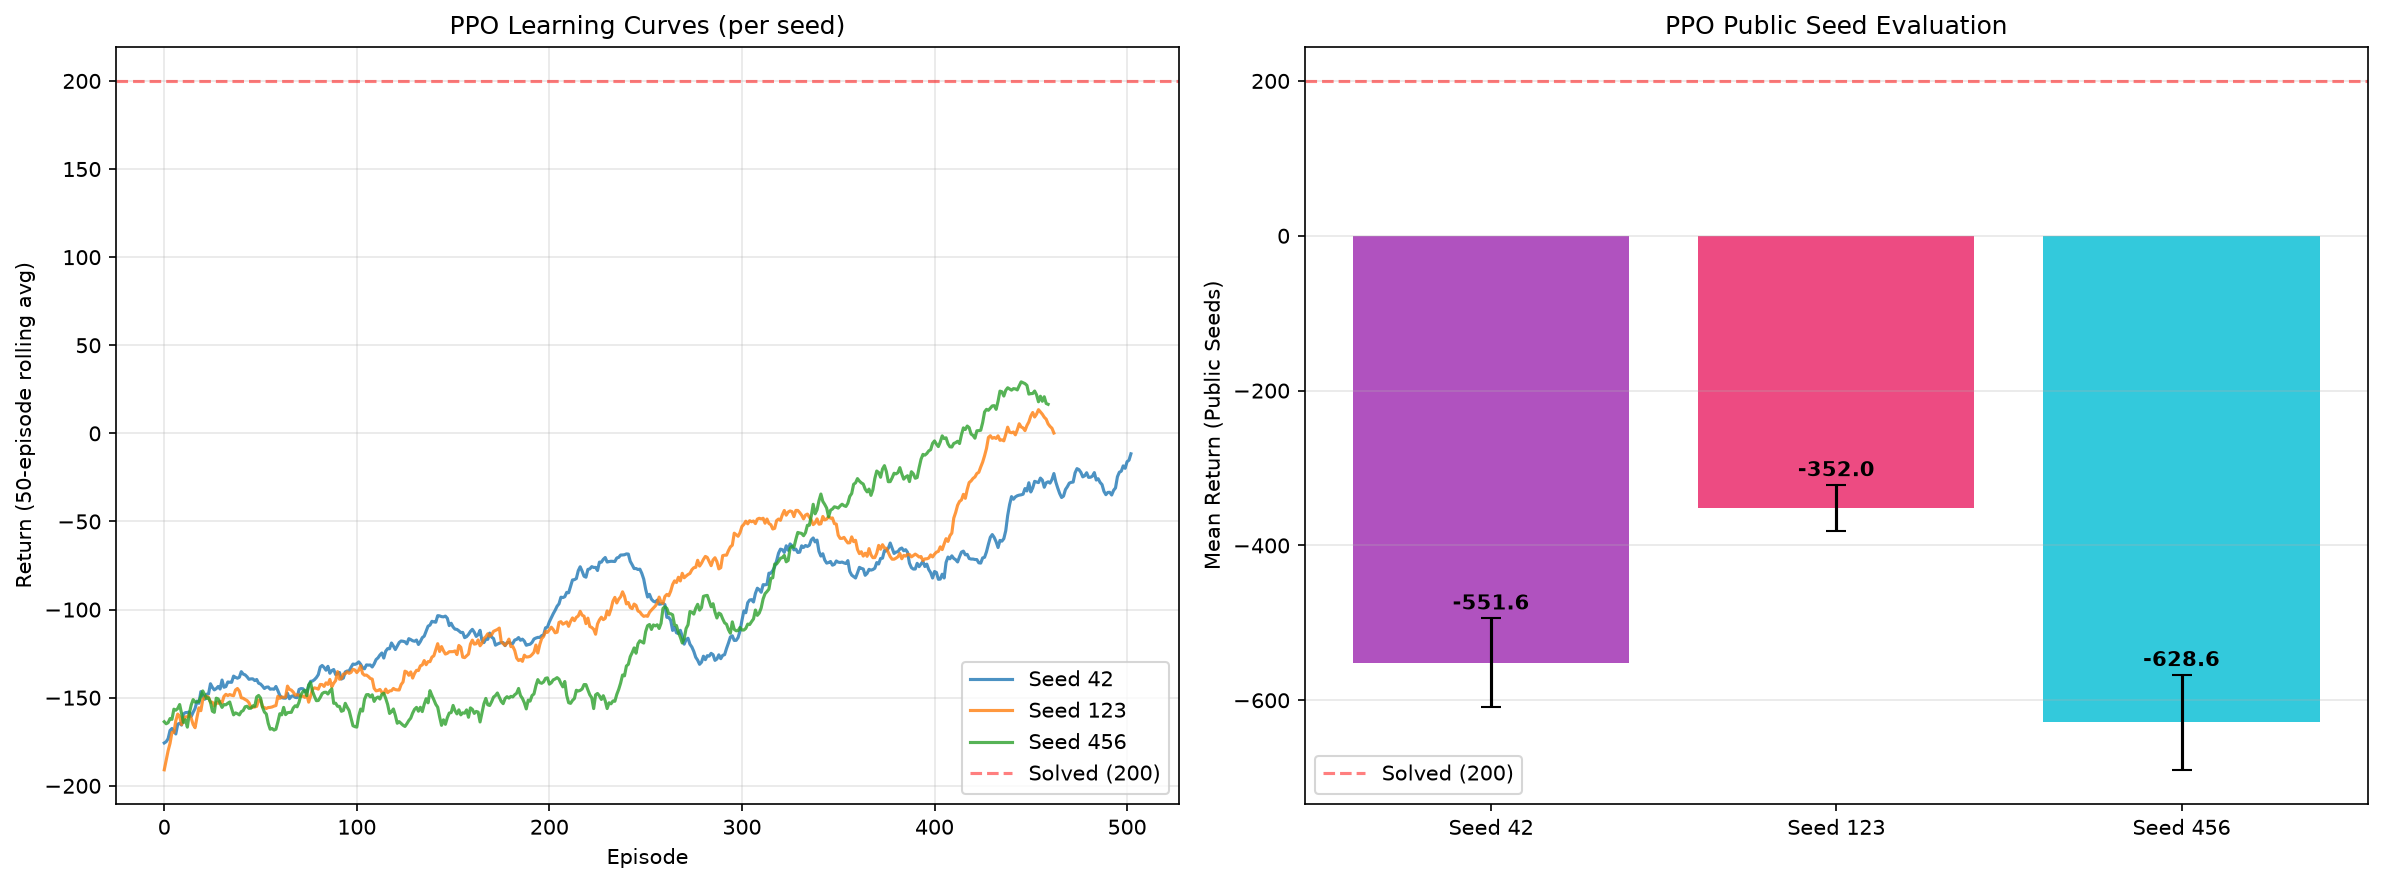

In [3]:
with open('checkpoints/ppo_results.json', 'r') as f:
    ppo_results = json.load(f)

means = [r['public_eval_mean'] for r in ppo_results]
best_idx = np.argmax(means)
best_seed = ppo_results[best_idx]['seed']

print("=== PPO Evaluation Results ===")
print(f"Mean return across seeds: {np.mean(means):.1f}")
print(f"Standard deviation: {np.std(means):.1f}")
print(f"Best seed: {best_seed} with return: {means[best_idx]:.1f}")
print("\nLoading Learning Curves Plot...")
display(Image(filename='plots/ppo_learning_curves.png'))